# Example: for GHZ state:

We prepare a GHZ state in $n$ number of qubits and execute it with the optimal layout vs a naive layout taken by default.

Note that this example and the framework of ``qubit_selector`` is based on ``qiskit``.


In [1]:
import os
import matplotlib.pyplot as plt
from iqm.qubit_selector.qubit_selector import *
from iqm.qubit_selector.qiskit_utils import get_circuit, CircuitType
from iqm.qiskit_iqm import IQMProvider, transpile_to_IQM
from qiskit.visualization import plot_histogram
from rustworkx.visualization import mpl_draw
from rustworkx import spring_layout

In [8]:
# Input your Resonance token
token = "XXXXXXXX"  # Replace with your actual token
os.environ["IQM_TOKEN"] = token

In [ ]:
iqm_server_url = "https://<your-iqm-server-url>"  # Replace with your IQM server URL if needed
provider = IQMProvider(iqm_server_url)
backend = provider.get_backend()
os.environ["IQM_SERVER_URL"] = iqm_server_url ## needs to be initialized as an environment variable for qubit_selector.

### Define the GHZ state and find the optimal layout.

In [5]:
nqubits = 6
# Possible choices for pre-defined circuits 'ghz', 'qft', 'random', 'wstate', 'quantum_volume' 'qaoa'
qc_algo = get_circuit(CircuitType.GHZ, nqubits) ## plug in your qiskit quantum circuit of interest

layouts, cost = CostEvaluator(backend=backend, quantum_circuit=qc_algo).get_top_layouts(num_layouts=50)
print("Top 10 qiskit layouts and their costs:")
for layout, c in zip(layouts[:10], cost[:10]):
    print(f"Layout: {layout}, Cost: {c*100:.2f}%")

[02-07 15:33:16;I] Number of layouts to evaluate: 378
[02-07 15:33:21;I] Cost evaluation has begun using cost function "gate_cost_cz".
Top 10 qiskit layouts and their costs:
Layout: [0, 1, 4, 9, 10, 15], Cost: 2.24%
Layout: [1, 4, 9, 10, 14, 15], Cost: 2.25%
Layout: [1, 4, 9, 10, 15, 19], Cost: 2.30%
Layout: [1, 4, 9, 10, 15, 16], Cost: 2.36%
Layout: [0, 1, 4, 9, 14, 15], Cost: 2.41%
Layout: [1, 4, 9, 14, 15, 19], Cost: 2.47%
Layout: [1, 4, 9, 14, 15, 16], Cost: 2.53%
Layout: [4, 9, 10, 15, 18, 19], Cost: 2.57%
Layout: [0, 1, 4, 8, 9, 13], Cost: 2.58%
Layout: [8, 13, 15, 17, 18, 19], Cost: 2.59%


### Execute on a naively chosen layout on the hardware:

[02-07 15:33:22;I] Waiting for job 019c3885-8b59-78e2-9940-873523064c89 to finish...


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

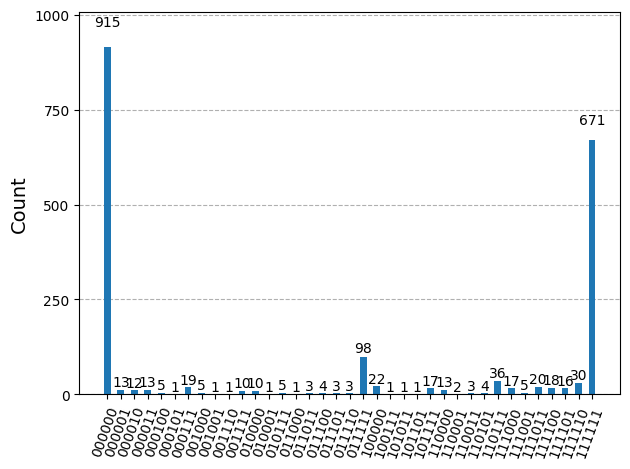

In [6]:
qc_t = transpile_to_IQM(qc_algo, backend=backend, optimization_level=3, optimize_single_qubits=True)
job = backend.run(qc_t, shots=2000).result()
counts = job.get_counts()
plot_histogram(counts)

### Execute on optimal layout found by qubit_selector:

As you see from the ``counts``, the GHZ state is better prepared by choosing the optinal layout from qubit-selector.

Best layout qubit names: ['QB1', 'QB2', 'QB5', 'QB10', 'QB11', 'QB16']
[02-07 15:33:34;I] Waiting for job 019c3885-b848-7820-aef6-6ebdb0def861 to finish...


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

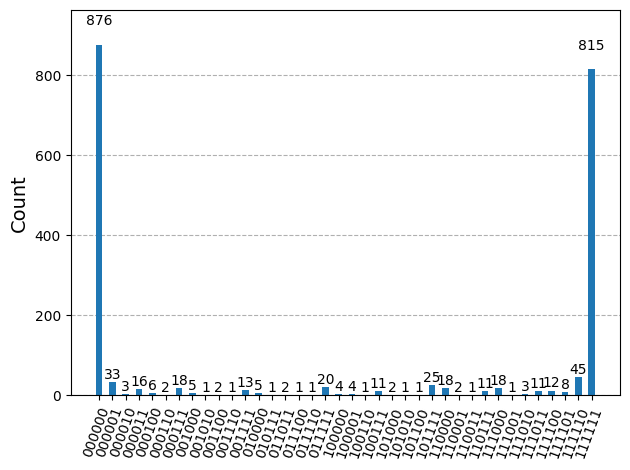

In [ ]:
best_layout = layouts[0]
best_layout_qubit_names = [backend.index_to_qubit_name(q) for q in best_layout] ## qubit names corresponding to the best layout

print(f"Best layout qubit names: {best_layout_qubit_names}")
qc_t = transpile_to_IQM(qc_algo, backend=backend, optimization_level=3, optimize_single_qubits=True, initial_layout=best_layout)
job = backend.run(qc_t, shots=2000).result()
counts = job.get_counts()
plot_histogram(counts)